In [ ]:
# =========================================================
# CELL 1 - IMPORT & KONFIGURASI
# =========================================================

import os, time, random, statistics
import sys
from pathlib import Path
from typing import List, Tuple, Optional, Any, Dict, Set
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Konfigurasi Eksperimen
DATA_PATH = "../data/test_final_50.csv"
RESULT_PATH = "../result/"
TIMEOUT_SEC = 90
REPEATS = 1 
base_seed = 42 

# Konfigurasi Sistem
sys.setrecursionlimit(200000)

Path(RESULT_PATH).mkdir(exist_ok=True)
random.seed(base_seed)
np.random.seed(base_seed)

print("Setup selesai.")

Setup selesai.


In [ ]:
# =========================================================
# CELL 2 - UTILITAS & CLASS SUDOKU SOLVER
# =========================================================

def parse_puzzle(puzzle_str: str) -> List[List[int]]:
    """Mengubah string puzzle menjadi format board 9x9 (list of lists)."""
    return [
        [0 if puzzle_str[i*9+j] == '.' else int(puzzle_str[i*9+j]) for j in range(9)]
        for i in range(9)
    ]

class SudokuSolver:
    """Class untuk menampung logika Sudoku Solver, dengan pelacakan nodes."""
    def __init__(self, time_limit: float):
        self.nodes = 0
        self.start_time = 0.0
        self.time_limit = time_limit

    def is_safe(self, board: List[List[int]], r: int, c: int, num: int) -> bool:
        """Memeriksa apakah penempatan num di (r, c) aman (Baris, Kolom, Box)."""
        # Check row dan column
        for i in range(9):
            if board[r][i] == num or board[i][c] == num:
                return False
        
        # Check 3x3 box
        sr, sc = r - r % 3, c - c % 3
        for i in range(3):
            for j in range(3):
                if board[sr+i][sc+j] == num:
                    return False
        return True

    # MRV (Minimum Remaining Value) HEURISTIC  
    
    def find_mrv(self, board: List[List[int]]) -> Optional[Tuple[int, int]]:
        """Mencari sel kosong dengan domain (nilai sisa) terkecil."""
        min_domain_size = 10
        pos = None
        for r in range(9):
            for c in range(9):
                if board[r][c] == 0:
                    # Menghitung domain size
                    count = sum(self.is_safe(board, r, c, n) for n in range(1, 10))
                    if count < min_domain_size:
                        min_domain_size = count
                        pos = (r, c)
                        if min_domain_size == 1: 
                            return pos 
        return pos

    def solve_mrv(self, board: List[List[int]]) -> bool:
        """Algoritma MRV: Backtracking + MRV Heuristic."""
        if time.time() - self.start_time > self.time_limit:
            return False

        pos = self.find_mrv(board)
        if not pos:
            return True 

        r, c = pos
        for n in range(1, 10):
            if self.is_safe(board, r, c, n):
                self.nodes += 1
                board[r][c] = n
                if self.solve_mrv(board):
                    return True
                board[r][c] = 0
        return False

    # FORWARD CHECKING (FC)

    def init_domains(self, board: List[List[int]]) -> List[List[Set[int]]]:
        """Menginisialisasi domain nilai yang mungkin untuk setiap sel kosong."""
        dom: List[List[Set[int]]] = [[set() for _ in range(9)] for _ in range(9)]
        for r in range(9):
            for c in range(9):
                if board[r][c] == 0:
                    for n in range(1, 10):
                        if self.is_safe(board, r, c, n):
                            dom[r][c].add(n)
        return dom

    def forward_check(self, domains: List[List[Set[int]]], r: int, c: int, val: int) -> bool:
        """
        Propagasi batasan (val) ke tetangga.
        Perbaikan: Memastikan sel (r, c) yang baru ditetapkan tidak dicek.
        """
        
        # 1. Row/Col Constraint Propagation
        for i in range(9):
            if i != r and val in domains[i][c]:
                domains[i][c].remove(val)
                if not domains[i][c]: return False
            if i != c and val in domains[r][i]:
                domains[r][i].remove(val)
                if not domains[r][i]: return False

        # 2. Box Constraint Propagation
        sr, sc = r - r % 3, c - c % 3
        for i in range(3):
            for j in range(3):
                rr, cc = sr+i, sc+j
                if (rr, cc) != (r, c) and val in domains[rr][cc]:
                    domains[rr][cc].remove(val)
                    if not domains[rr][cc]: return False
        return True

    def find_empty(self, board: List[List[int]]) -> Optional[Tuple[int, int]]:
        """
        Mencari sel kosong pertama. Digunakan untuk FC Murni (Sequential Selection).
        """
        for r in range(9):
            for c in range(9):
                if board[r][c] == 0:
                    return r, c
        return None

    def solve_fc(self, board: List[List[int]], domains: Optional[List[List[Set[int]]]] = None) -> bool:
        """Algoritma FC: Backtracking + Forward Checking + Sequential Selection."""
        if time.time() - self.start_time > self.time_limit:
            return False

        if domains is None:
            domains = self.init_domains(board)
            if any(not domains[r][c] for r in range(9) for c in range(9) if board[r][c] == 0):
                return False

        pos = self.find_empty(board) 
        
        if not pos:
            return True

        r, c = pos
        
        for val in list(domains[r][c]):
            self.nodes += 1
            board[r][c] = val
            
            backup_domains = [[d.copy() for d in row] for row in domains]

            domains[r][c].clear() 

            if self.forward_check(domains, r, c, val):
                if self.solve_fc(board, domains):
                    return True

            board[r][c] = 0
            domains = backup_domains 
            
        return False

In [ ]:
# =========================================================
# CELL 3 - IMPLEMENTASI ALGORITMA 
# =========================================================

def algo_A(instance: str) -> Tuple[Optional[List[List[int]]], int, bool]:
    """Algoritma A: Backtracking dengan MRV heuristic."""
    board = parse_puzzle(instance)
    solver = SudokuSolver(time_limit=TIMEOUT_SEC)
    solver.start_time = time.time()
    
    success = solver.solve_mrv(board)
    
    return ([r[:] for r in board]) if success else None, solver.nodes, success

def algo_B(instance: str) -> Tuple[Optional[List[List[int]]], int, bool]:
    """Algoritma B: Backtracking dengan Forward Checking (FC)."""
    board = parse_puzzle(instance)
    solver = SudokuSolver(time_limit=TIMEOUT_SEC)
    solver.start_time = time.time()
    
    success = solver.solve_fc(board) 
    
    return ([r[:] for r in board]) if success else None, solver.nodes, success

In [ ]:
# =========================================================
# CELL 4 - LOADER INSTANCE
# =========================================================

def load_instances(path: str) -> pd.DataFrame:
    """Memuat dataset Sudoku dari file CSV."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"File tidak ditemukan: {path}. Pastikan path relatif sudah benar.")
             
    df = pd.read_csv(path)
    df_inst = df[["id", "puzzle"]].copy() 
    print(f"Dataset dimuat: {len(df_inst)} Sudoku")
    return df_inst

df_sudoku = load_instances(DATA_PATH)
total_puzzles = len(df_sudoku)
print(f"Total {total_puzzles} puzzle dimuat.")

Dataset dimuat: 50 Sudoku
Total 50 puzzle dimuat.


In [ ]:
# =========================================================
# CELL 5 - EVALUATOR & TIMING
# =========================================================

def check_sudoku_validity(board: Optional[List[List[int]]]) -> bool:
    """Memeriksa apakah papan Sudoku 9x9 adalah solusi yang valid dan lengkap."""
    if board is None:
        return False
    
    def get_unit_values(unit: List[int]) -> bool:
        filled_values = [v for v in unit if v != 0]
        return len(filled_values) == 9 and len(set(filled_values)) == 9
        
    for i in range(9):
        if not get_unit_values(board[i]): return False
        if not get_unit_values([board[r][i] for r in range(9)]): return False
        
    # Check 3x3 boxes
    for box_r in range(0, 9, 3):
        for box_c in range(0, 9, 3):
            box = [board[r][c] 
                   for r in range(box_r, box_r + 3) 
                   for c in range(box_c, box_c + 3)]
            if not get_unit_values(box): return False
            
    return True

def evaluate_solution(result: Tuple[Optional[List[List[int]]], int, bool]) -> float:
    """Mengembalikan 0.0 jika berhasil dipecahkan, 1.0 jika gagal/timeout."""
    solution_board, nodes, success = result
    if success and check_sudoku_validity(solution_board):
        return 0.0 
    return 1.0 


def run_once(algorithm, instance: str) -> Dict[str, Any]:
    """Menjalankan algoritma sekali dan mengukur metrik."""
    t0 = time.perf_counter()
    solution, nodes, success = algorithm(instance)
    dt = (time.perf_counter() - t0) * 1000.0 # Time in ms
    
    gap = evaluate_solution((solution, nodes, success))

    return {
        'time_ms': dt, 
        'nodes': nodes, 
        'gap': gap, 
        'success': success,
        'solution': solution 
    }

In [ ]:
# =========================================================
# CELL 6 - EKSEKUSI EKSPERIMEN 
# =========================================================

algos = {'MRV': algo_A, 'FC': algo_B} 
rows = []
html_data_storage = {} 

total_puzzles = len(df_sudoku)
total_runs = total_puzzles * REPEATS * len(algos)
current_run_count = 0

print(f"Memulai eksperimen: {total_puzzles} puzzle, {REPEATS} ulangan/puzzle. Total {total_runs} runs.")
start_experiment_time = time.time()

# Loop berdasarkan puzzle ID
for puzzle_idx, puzzle_row in df_sudoku.iterrows():
    pid = int(puzzle_row["id"])
    puzzle_str = puzzle_row["puzzle"]

    puzzle_progress = f"[{puzzle_idx + 1}/{total_puzzles}] Sudoku ID {pid}"
    print(f"\nProcessing {puzzle_progress}...")
    
    html_data_storage[pid] = {
        "initial": parse_puzzle(puzzle_str),
        "MRV": None,
        "FC": None
    }

    for repeat in range(REPEATS):
        algo_keys = list(algos.keys())
        random.shuffle(algo_keys) 
        
        for algo_name in algo_keys:
            current_run_count += 1
            algo_func = algos[algo_name]
            
            run_start_time = time.time()
            print(f"  > Run {current_run_count}/{total_runs} (Algo: {algo_name})", end="", flush=True)

            result = run_once(algo_func, puzzle_str)
            run_duration = (time.time() - run_start_time) * 1000
            
            status = "SOLVED" if result['success'] else "TIMEOUT"
            print(f" -> Status: {status}, Time: {run_duration:.2f} ms")

            rows.append({
                'id': pid,
                'repeat': repeat,
                'algo': algo_name,
                'time_ms': result['time_ms'],
                'nodes': result['nodes'],
                'gap': result['gap'],
                'success': result['success']
            })
            
            if repeat == 0:
                html_data_storage[pid][algo_name] = {
                    "status": status,
                    "time": round(result['time_ms'], 2),
                    "nodes": result['nodes'],
                    "solution": result['solution']
                }


df_raw = pd.DataFrame(rows)
df_raw.to_csv(f'{RESULT_PATH}/experiment_raw.csv', index=False)


summary = df_raw.groupby(['algo']).agg(
    puzzle_solved=('success', 'sum'),
    time_ms_mean=('time_ms', 'mean'),
    time_ms_sd=('time_ms', 'std'),
    nodes_mean=('nodes', 'mean'),
    nodes_sd=('nodes', 'std'),
    gap_mean=('gap', 'mean')
).reset_index()

summary['success_rate'] = (summary['puzzle_solved'] / (total_puzzles * REPEATS)) * 100 
summary.to_csv(f'{RESULT_PATH}/summary.csv', index=False)

total_experiment_time = time.time() - start_experiment_time
print(f"\n==================================================================")
print(f"Eksperimen selesai. Total {len(df_raw)} run dalam {total_experiment_time:.2f} detik.")
print(f"==================================================================")
display(summary)

Memulai eksperimen: 50 puzzle, 1 ulangan/puzzle. Total 100 runs.

Processing [1/50] Sudoku ID 1...
  > Run 1/100 (Algo: FC) -> Status: TIMEOUT, Time: 90006.52 ms
  > Run 2/100 (Algo: MRV) -> Status: SOLVED, Time: 11560.24 ms

Processing [2/50] Sudoku ID 2...
  > Run 3/100 (Algo: FC) -> Status: TIMEOUT, Time: 90006.07 ms
  > Run 4/100 (Algo: MRV) -> Status: SOLVED, Time: 58462.68 ms

Processing [3/50] Sudoku ID 3...
  > Run 5/100 (Algo: FC) -> Status: SOLVED, Time: 14927.69 ms
  > Run 6/100 (Algo: MRV) -> Status: SOLVED, Time: 1997.67 ms

Processing [4/50] Sudoku ID 4...
  > Run 7/100 (Algo: MRV) -> Status: SOLVED, Time: 50485.43 ms
  > Run 8/100 (Algo: FC) -> Status: SOLVED, Time: 17513.05 ms

Processing [5/50] Sudoku ID 5...
  > Run 9/100 (Algo: FC) -> Status: SOLVED, Time: 52172.08 ms
  > Run 10/100 (Algo: MRV) -> Status: SOLVED, Time: 32358.49 ms

Processing [6/50] Sudoku ID 6...
  > Run 11/100 (Algo: MRV) -> Status: SOLVED, Time: 25392.42 ms
  > Run 12/100 (Algo: FC) -> Status: SOL

,algo,puzzle_solved,time_ms_mean,time_ms_sd,nodes_mean,nodes_sd,gap_mean,success_rate
0,FC,36,46639.708664,33615.92628,292336.22,213852.967172,0.28,72.0
1,MRV,50,16735.196890,15408.25306,31113.52,29386.980903,0.00,100.0


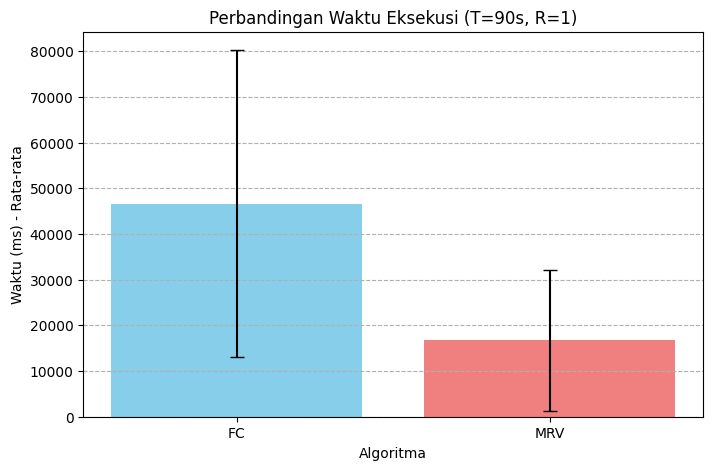

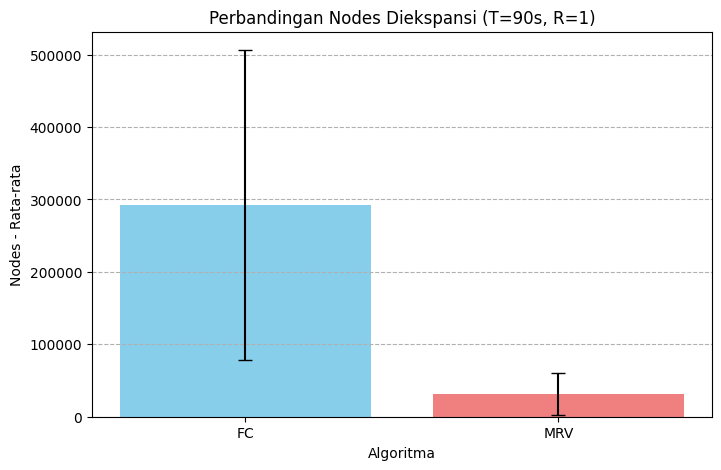

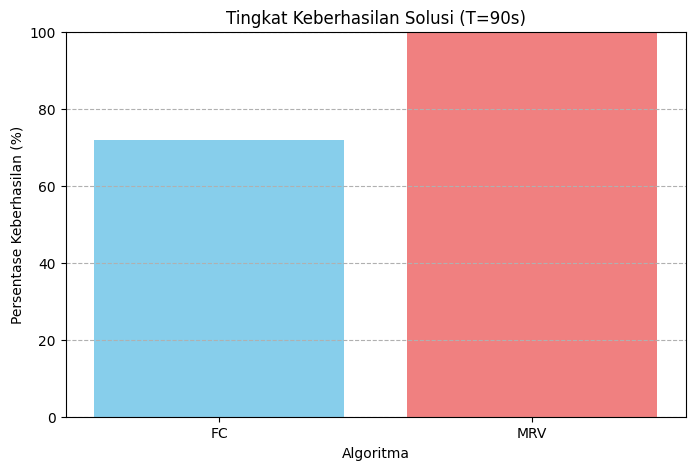

In [ ]:
# =========================================================
# CELL 7 - PLOT & TABEL
# =========================================================

# 1. Plot Waktu
plt.figure(figsize=(8, 5))
plt.bar(summary['algo'], summary['time_ms_mean'], yerr=summary['time_ms_sd'], capsize=5, color=['skyblue', 'lightcoral'])
plt.title(f'Perbandingan Waktu Eksekusi (T={TIMEOUT_SEC}s, R={REPEATS})')
plt.ylabel('Waktu (ms) - Rata-rata')
plt.xlabel('Algoritma')
plt.grid(axis='y', linestyle='--')
plt.savefig(f'{RESULT_PATH}/time_comparison.png')
plt.show()

# 2. Plot Node
plt.figure(figsize=(8, 5))
plt.bar(summary['algo'], summary['nodes_mean'], yerr=summary['nodes_sd'], capsize=5, color=['skyblue', 'lightcoral'])
plt.title(f'Perbandingan Nodes Diekspansi (T={TIMEOUT_SEC}s, R={REPEATS})')
plt.ylabel('Nodes - Rata-rata')
plt.xlabel('Algoritma')
plt.grid(axis='y', linestyle='--')
plt.savefig(f'{RESULT_PATH}/nodes_comparison.png')
plt.show()
 
# 3. Plot Success Rate
plt.figure(figsize=(8, 5))
plt.bar(summary['algo'], summary['success_rate'], color=['skyblue', 'lightcoral'])
plt.title(f'Tingkat Keberhasilan Solusi (T={TIMEOUT_SEC}s)')
plt.ylabel('Persentase Keberhasilan (%)')
plt.xlabel('Algoritma')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--')
plt.savefig(f'{RESULT_PATH}/success_rate.png')
plt.show()

In [ ]:
# =========================================================
# CELL 8 - EKSPOR TABEL LATEX
# =========================================================

latex_summary = summary.rename(columns={
    'algo': 'Algoritma',
    'puzzle_solved': 'Total Solved',
    'time_ms_mean': 'Waktu Rata-rata (ms)',
    'time_ms_sd': 'SD Waktu (ms)',
    'nodes_mean': 'Nodes Rata-rata',
    'nodes_sd': 'SD Nodes',
    'gap_mean': 'Gap Rata-rata',
    'success_rate': 'Success Rate (%)'
})


latex_table_cols = [
    'Algoritma', 
    'Total Solved',
    'Success Rate (%)', 
    'Waktu Rata-rata (ms)', 
    'SD Waktu (ms)',
    'Nodes Rata-rata', 
    'SD Nodes'
]

latex_table = latex_summary[latex_table_cols].to_latex(
    index=False,
    float_format="%.2f",
    caption=f"Perbandingan Performa Sudoku Solver (MRV vs FC) pada {total_puzzles} Puzzle (T={TIMEOUT_SEC}s, R={REPEATS})",
    label="tab:sudoku_summary"
)

with open(f'{RESULT_PATH}/summary.tex', 'w') as f:
    f.write(latex_table)
    
print(f"Summary LaTeX berhasil disimpan di {RESULT_PATH}/summary.tex")
print("\nPreview Tabel LaTeX:")
print(latex_table)

Summary LaTeX berhasil disimpan di ../result//summary.tex

Preview Tabel LaTeX:
\begin{table}
\caption{Perbandingan Performa Sudoku Solver (MRV vs FC) pada 50 Puzzle (T=90s, R=1)}
\label{tab:sudoku_summary}
\begin{tabular}{lrrrrrr}
\toprule
Algoritma & Total Solved & Success Rate (%) & Waktu Rata-rata (ms) & SD Waktu (ms) & Nodes Rata-rata & SD Nodes \\
\midrule
FC & 36 & 72.00 & 46639.71 & 33615.93 & 292336.22 & 213852.97 \\
MRV & 50 & 100.00 & 16735.20 & 15408.25 & 31113.52 & 29386.98 \\
\bottomrule
\end{tabular}
\end{table}



In [56]:
# =========================================================
# CELL 9 - EKSPOR DASHBOARD HTML 
# =========================================================

def export_dashboard(data: Dict[int, Any]):
    """
    Menghasilkan file HTML dashboard dari data hasil run pertama.
    Data harus sudah dalam format {id: {initial: ..., MRV: {status, time, nodes, solution}, FC: {...}}}
    """
    options = "\n".join(
        f'<option value="{k}">Sudoku {k}</option>' for k in data.keys()
    )

    html = f"""
<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>Sudoku Solver Comparison: MRV vs Forward Checking</title>
<style>
body {{ font-family: Arial; }}
table {{ border-collapse: collapse; margin-bottom: 20px; border: 2px solid #000; }}
td {{ 
    width: 30px; height: 30px; border: 1px solid #999; text-align: center; 
    font-size: 16px; font-weight: bold;
}}
tr:nth-child(3n) td {{ border-bottom: 2px solid #000; }}
td:nth-child(3n) {{ border-right: 2px solid #000; }}
tr:last-child td {{ border-bottom: 1px solid #999; }} 
td:last-child {{ border-right: 1px solid #999; }}

.section {{ margin-top: 20px; padding: 10px; border-top: 1px solid #ccc; }}
h3 {{ color: #333; }}
</style>
</head>
<body>

<h1>Sudoku Solver Comparison (Case-by-Case)</h1>

<select id="sid" onchange="render()">
{options}
</select>

<div class="section">
<h3>Initial State</h3>
<div id="init"></div>
</div>

<div class="section">
<h3>MRV (Minimum Remaining Value) Result</h3>
<pre id="mrv"></pre>
<div id="mrv_sol"></div>
</div>

<div class="section">
<h3>Forward Checking (FC) Result</h3>
<pre id="fc"></pre>
<div id="fc_sol"></div>
</div>

<script>
const DATA = {json.dumps(data)};

function table(grid) {{
    if (!grid) return "<table><tr><td>No Solution/Timeout</td></tr></table>";
    let h = "<table>";
    for (let r of grid) {{
        h += "<tr>";
        for (let c of r) h += "<td>" + (c || "") + "</td>";
        h += "</tr>";
    }}
    return h + "</table>";
}}

function render() {{
    let d = DATA[document.getElementById("sid").value];
    if (!d) return;

    document.getElementById("init").innerHTML = table(d.initial);

    // MRV
    document.getElementById("mrv").innerText =
        "Status: " + d.MRV.status + "\\n" +
        "Time: " + d.MRV.time + " ms\\n" +
        "Nodes: " + d.MRV.nodes;
    document.getElementById("mrv_sol").innerHTML = table(d.MRV.solution);

    // FC
    document.getElementById("fc").innerText =
        "Status: " + d.FC.status + "\\n" +
        "Time: " + d.FC.time + " ms\\n" +
        "Nodes: " + d.FC.nodes;
    document.getElementById("fc_sol").innerHTML = table(d.FC.solution);
}}

render();
</script>

</body>
</html>
"""

    with open(f"{RESULT_PATH}/dashboard_sudoku_case_by_case.html", "w", encoding="utf-8") as f:
        f.write(html)

export_dashboard(html_data_storage)
print("Dashboard case-by-case berhasil dibuat.")

Dashboard case-by-case berhasil dibuat.
